<a href="https://colab.research.google.com/github/GIVEN-CHINYAMA/Cyclistic_Bike_Share_Analysis./blob/main/Cyclistic_Bike_Share_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Cyclistic_Bike_Share_Analysis

In [ ]:
import pandas as pd
import glob
import os

# 1. Set your verified path
path = '/content/drive/MyDrive/Cyclistic_Project'
all_files = glob.glob(os.path.join(path, "*.csv"))

if len(all_files) > 0:
    # 2. Merge all 12 months into one big table (DataFrame)
    df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)

    # 3. Convert dates from text to actual Date objects
    df['started_at'] = pd.to_datetime(df['started_at'])
    df['ended_at'] = pd.to_datetime(df['ended_at'])

    # 4. Create 'ride_length' (Total time of the trip)
    df['ride_length'] = df['ended_at'] - df['started_at']

    # 5. Create 'day_of_week' (1=Sun, 7=Sat as per Case Study)
    df['day_of_week'] = df['started_at'].dt.dayofweek + 1

    print(f"Success! {len(all_files)} files merged.")
    print(f"Total rows for your analysis: {df.shape[0]}")
else:
    print("Files not found. Make sure the .csv files are directly inside the 'Cyclistic_Project' folder.")

Success! 12 files merged.
Total rows for your analysis: 5552994


In [ ]:
df.isnull().sum()

,0
ride_id,0
rideable_type,0
started_at,0
ended_at,0
start_station_name,1184673
start_station_id,1184673
end_station_name,1243305
end_station_id,1243305
start_lat,0
start_lng,0


In [ ]:
# Keep only rides longer than 0 seconds
df = df[df['ride_length'] > pd.Timedelta(0)]
print(f"Cleaned rows remaining: {df.shape[0]}")

Cleaned rows remaining: 5552965


In [ ]:
# Calculate descriptive statistics for ride_length by user type
summary_stats = df.groupby('member_casual')['ride_length'].describe()
print("Summary Statistics by User Type:")
print(summary_stats)

# Calculate the average ride length for each day of the week for both groups
avg_ride_by_day = df.pivot_table(values='ride_length',
                                 index='day_of_week',
                                 columns='member_casual',
                                 aggfunc='mean')
print("\nAverage Ride Length by Day:")
print(avg_ride_by_day)

Summary Statistics by User Type:
                 count                       mean                        std  \
member_casual                                                                  
casual         1999488  0 days 00:22:35.755487738  0 days 01:21:25.348243211   
member         3553477  0 days 00:12:19.941371841  0 days 00:31:17.195040197   

                                  min                     25%  \
member_casual                                                   
casual         0 days 00:00:00.046000  0 days 00:06:18.388000   
member         0 days 00:00:00.078000  0 days 00:05:01.838000   

                                  50%                     75%  \
member_casual                                                   
casual         0 days 00:11:24.395500  0 days 00:21:09.626500   
member         0 days 00:08:34.673000  0 days 00:14:30.333000   

                                  max  
member_casual                          
casual         1 days 02:14:54.011000  
memb

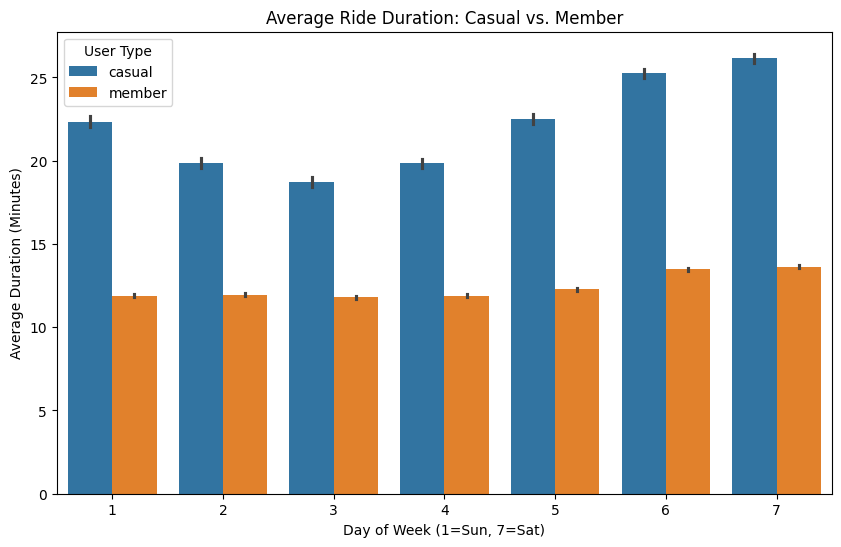

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert ride_length to minutes for easier reading in the chart
df['ride_length_m'] = df['ride_length'].dt.total_seconds() / 60

plt.figure(figsize=(10,6))
sns.barplot(data=df, x='day_of_week', y='ride_length_m', hue='member_casual')
plt.title('Average Ride Duration: Casual vs. Member')
plt.xlabel('Day of Week (1=Sun, 7=Sat)')
plt.ylabel('Average Duration (Minutes)')
plt.legend(title='User Type')
plt.show()

Top 10 Most Popular Stations for Casual Riders:
start_station_name
DuSable Lake Shore Dr & Monroe St     31326
Navy Pier                             27414
Streeter Dr & Grand Ave               23697
Michigan Ave & Oak St                 22430
DuSable Lake Shore Dr & North Blvd    19438
Millennium Park                       19099
Shedd Aquarium                        16848
Theater on the Lake                   15707
Dusable Harbor                        15646
Michigan Ave & 8th St                 11216
Name: count, dtype: int64


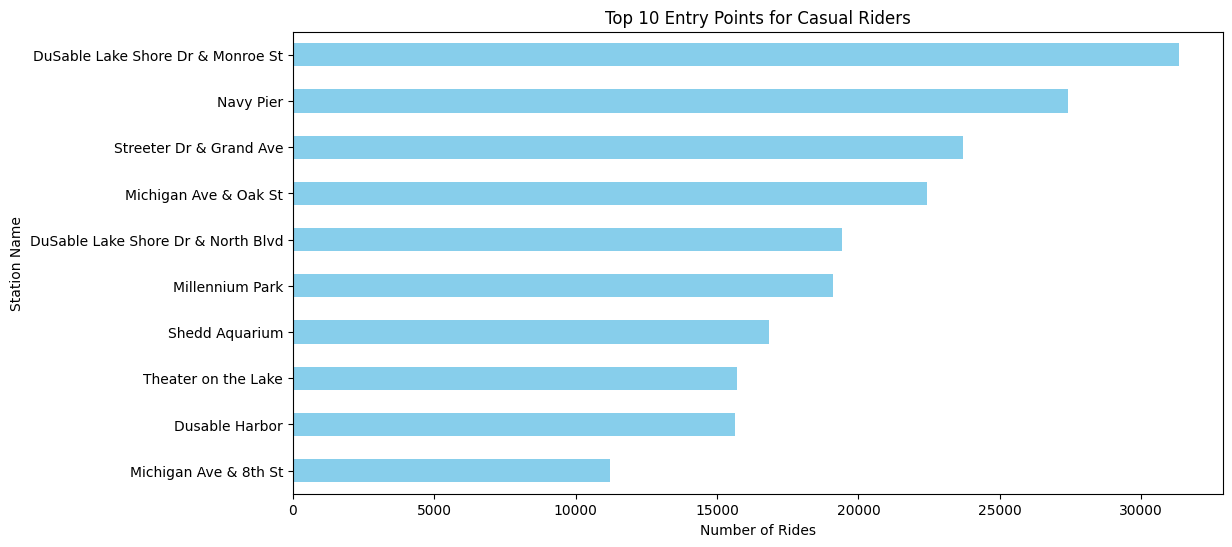

In [ ]:
# Filter for casual riders only and count their top starting stations
top_casual_stations = df[df['member_casual'] == 'casual']['start_station_name'].value_counts().head(10)

print("Top 10 Most Popular Stations for Casual Riders:")
print(top_casual_stations)

# Visualize it for your report
plt.figure(figsize=(12,6))
top_casual_stations.plot(kind='barh', color='skyblue').invert_yaxis()
plt.title('Top 10 Entry Points for Casual Riders')
plt.xlabel('Number of Rides')
plt.ylabel('Station Name')
plt.show()

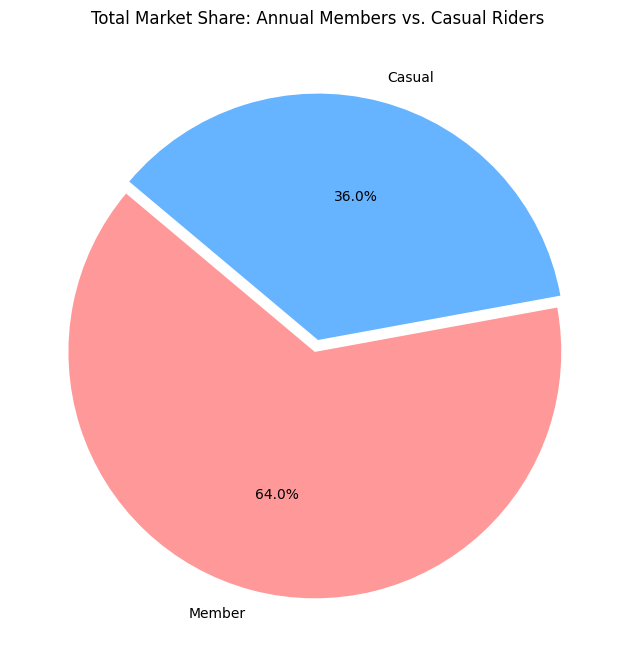

In [ ]:
# Create data for the pie chart based on your counts (3,553,477 vs 1,999,488)
labels = ['Member', 'Casual']
sizes = [3553477, 1999488]
colors = ['#ff9999','#66b3ff']

plt.figure(figsize=(8,8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.05, 0))
plt.title('Total Market Share: Annual Members vs. Casual Riders')
plt.show()

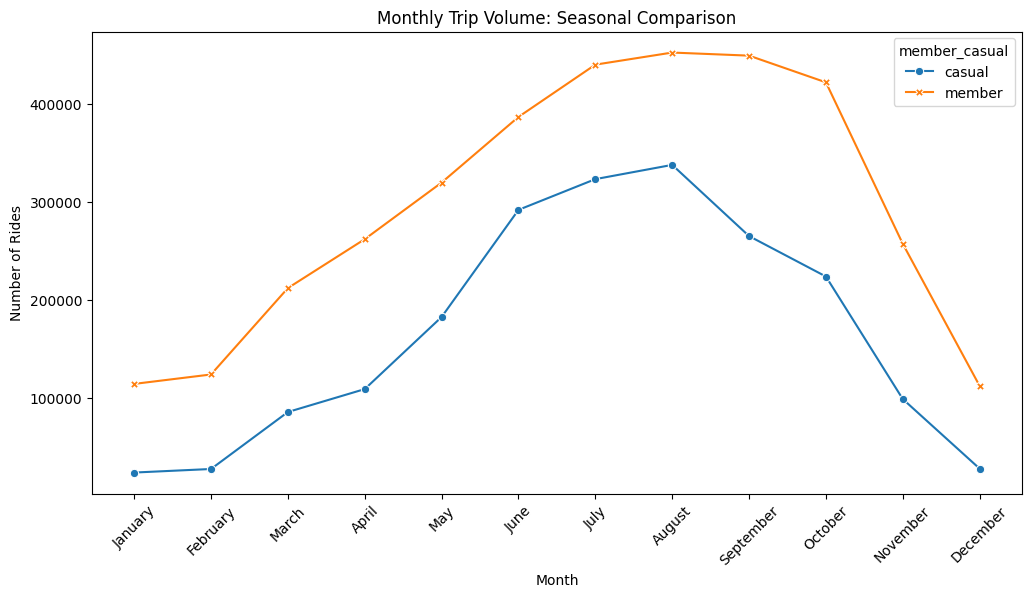

In [ ]:
# 1. Create a 'month' column
df['month'] = df['started_at'].dt.month_name()

# 2. Sort months correctly
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# 3. Group by month and user type
monthly_rides = df.groupby(['month', 'member_casual']).size().unstack().reindex(month_order)

# 4. Plot the Line Graph
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_rides, markers=True, dashes=False)
plt.title('Monthly Trip Volume: Seasonal Comparison')
plt.ylabel('Number of Rides')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.show()

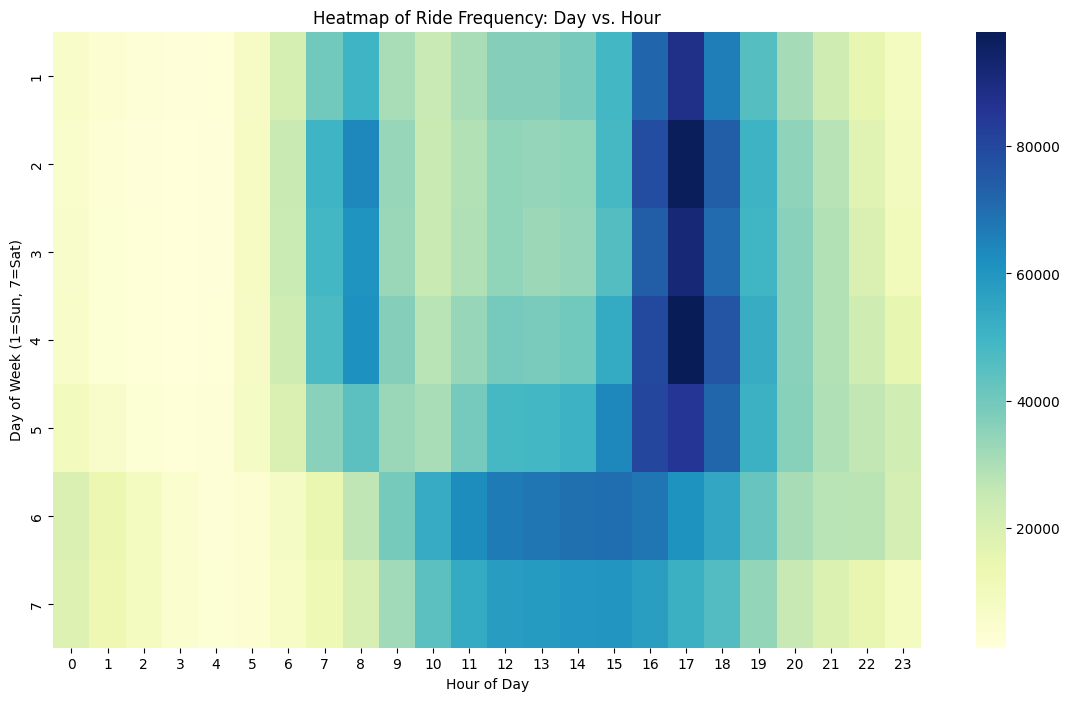

In [ ]:
# Extract the hour from the start time
df['hour'] = df['started_at'].dt.hour

# Create a pivot table for the heatmap
heatmap_data = df.groupby(['day_of_week', 'hour']).size().unstack()

plt.figure(figsize=(14,8))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False)
plt.title('Heatmap of Ride Frequency: Day vs. Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week (1=Sun, 7=Sat)')
plt.show()

In [ ]:
# Calculate the total number of rides for each group
total_rides = df['member_casual'].value_counts()

# Calculate the average ride length (in minutes) for each group
avg_ride_mins = df.groupby('member_casual')['ride_length_m'].mean()

print("--- FINAL KEY FINDINGS ---")
print(f"Total Rides: \n{total_rides}\n")
print(f"Average Ride Duration (Minutes): \n{avg_ride_mins}")

--- FINAL KEY FINDINGS ---
Total Rides: 
member_casual
member    3553477
casual    1999488
Name: count, dtype: int64

Average Ride Duration (Minutes): 
member_casual
casual    22.595925
member    12.332356
Name: ride_length_m, dtype: float64


Executive Interpretation of Findings

1. ​The Usage Gap: Casual riders use our bikes for nearly double the duration (22.6 minutes) compared to members (12.3 minutes). This indicates that casual riders are likely engaged in recreational or tourist activities, whereas members use the service for efficient, time-sensitive transit.
2. ​Growth Opportunity: With nearly 2 million casual rides recorded in a year, there is a massive untapped audience that already values the service but hasn't committed to a membership yet.
3. ​Strategic Direction: To convert these users, our marketing should not focus on "commuting speed" (which appeals to members), but rather on the cost-savings and convenience for long-duration weekend trips.

** Strategic Recommendations**
1. Develop a "Weekend-Only" Membership: Since casual ridership spikes heavily on Saturdays and Sundays with much longer trip durations, a low-cost weekend tier would capture users who don't need a weekday commuter pass.
2. Focus Marketing at Tourist Hubs: Launch targeted digital and physical ad campaigns at the top 5 casual start stations, specifically DuSable Lake Shore Dr and Monroe St and Navy Pier.
3. Seasonal Conversion Incentives: Run a "Spring Starter" promotion in May. Data shows casual ridership begins to climb in late spring; catching them early with a discount on an annual membership could convert them before their peak summer usage.